In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
features_df = pd.read_csv('/content/features.csv')
stores_df = pd.read_csv('/content/stores.csv')
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

# Display the first few rows of each dataset
print("Features Dataset:")
print(features_df.head())

print("\nStores Dataset:")
print(stores_df.head())

print("\nTrain Dataset:")
print(train_df.head())

print("\nTest Dataset:")
print(test_df.head())


FileNotFoundError: [Errno 2] No such file or directory: '/content/features.csv'

In [ ]:
# Check data information and null values for each dataset
print("\nFeatures Dataset Info:")
print(features_df.info())
print("\nMissing Values in Features Dataset:")
print(features_df.isnull().sum())

print("\nStores Dataset Info:")
print(stores_df.info())
print("\nMissing Values in Stores Dataset:")
print(stores_df.isnull().sum())

print("\nTrain Dataset Info:")
print(train_df.info())
print("\nMissing Values in Train Dataset:")
print(train_df.isnull().sum())

print("\nTest Dataset Info:")
print(test_df.info())
print("\nMissing Values in Test Dataset:")
print(test_df.isnull().sum())



Features Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB
None

Missing Values in Features Dataset:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkD

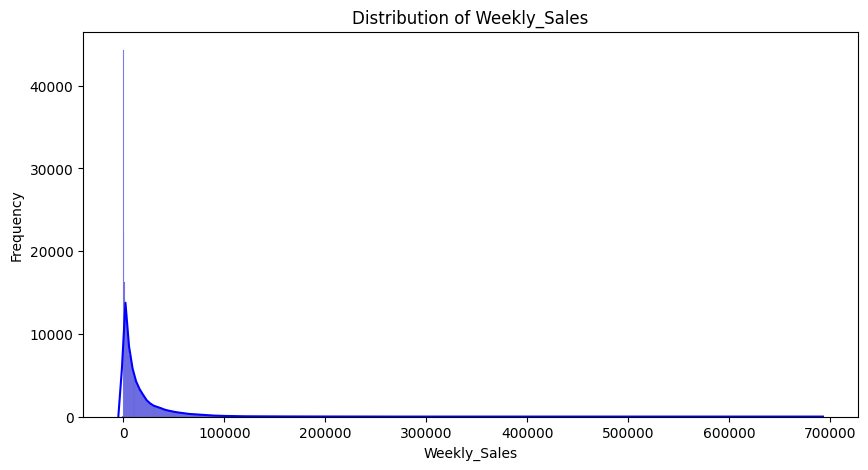

In [ ]:
# Visualize the distributions of key numerical columns
numerical_columns = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

for col in numerical_columns:
    if col in train_df.columns:
        plt.figure(figsize=(10, 5))
        sns.histplot(train_df[col], kde=True, color='blue')
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


In [ ]:
# Check for duplicate rows in each dataset
print("\nChecking for duplicates:")
print(f"Features Dataset: {features_df.duplicated().sum()} duplicates")
print(f"Stores Dataset: {stores_df.duplicated().sum()} duplicates")
print(f"Train Dataset: {train_df.duplicated().sum()} duplicates")
print(f"Test Dataset: {test_df.duplicated().sum()} duplicates")



Checking for duplicates:
Features Dataset: 0 duplicates
Stores Dataset: 0 duplicates
Train Dataset: 0 duplicates
Test Dataset: 0 duplicates


In [ ]:
# Display descriptive statistics for each dataset
print("\nFeatures Dataset Statistics:")
print(features_df.describe())

print("\nStores Dataset Statistics:")
print(stores_df.describe())

print("\nTrain Dataset Statistics:")
print(train_df.describe())

print("\nTest Dataset Statistics:")
print(test_df.describe())

# If categorical data exists, display unique value counts
print("\nUnique values in categorical columns for Train Dataset:")
for col in train_df.select_dtypes(include=['object']).columns:
    print(f"{col}:")
    print(train_df[col].value_counts())
    print()



Features Dataset Statistics:
             Store  Temperature   Fuel_Price      MarkDown1      MarkDown2  \
count  8190.000000  8190.000000  8190.000000    4032.000000    2921.000000   
mean     23.000000    59.356198     3.405992    7032.371786    3384.176594   
std      12.987966    18.678607     0.431337    9262.747448    8793.583016   
min       1.000000    -7.290000     2.472000   -2781.450000    -265.760000   
25%      12.000000    45.902500     3.041000    1577.532500      68.880000   
50%      23.000000    60.710000     3.513000    4743.580000     364.570000   
75%      34.000000    73.880000     3.743000    8923.310000    2153.350000   
max      45.000000   101.950000     4.468000  103184.980000  104519.540000   

           MarkDown3     MarkDown4      MarkDown5          CPI  Unemployment  
count    3613.000000   3464.000000    4050.000000  7605.000000   7605.000000  
mean     1760.100180   3292.935886    4132.216422   172.460809      7.826821  
std     11276.462208   6792.32

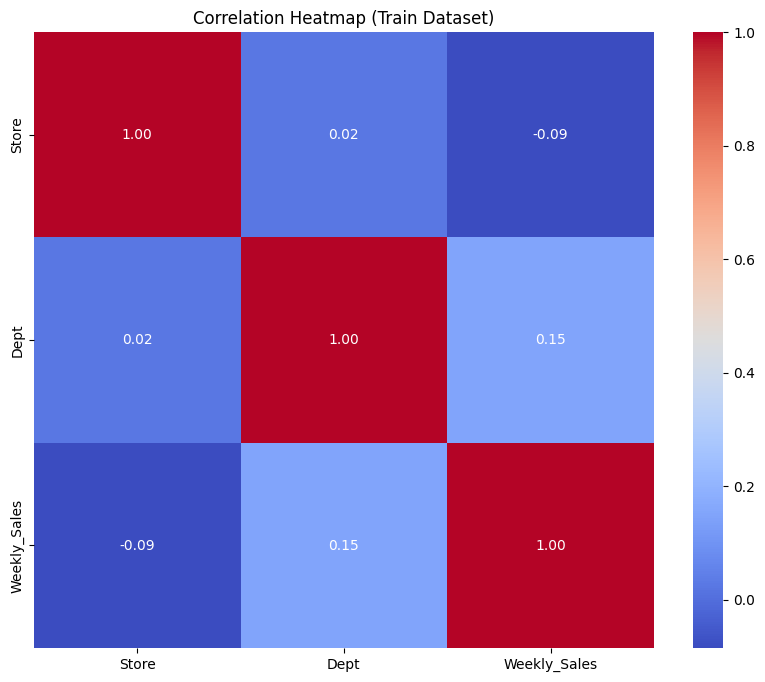

In [ ]:
# Select numerical columns for correlation
numerical_cols = train_df.select_dtypes(include=[np.number]).columns

# Check if there are numerical columns to plot
if len(numerical_cols) > 0:
    plt.figure(figsize=(10, 8))
    sns.heatmap(train_df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title("Correlation Heatmap (Train Dataset)")
    plt.show()
else:
    print("No numerical columns available for correlation heatmap.")


In [ ]:
# Fill missing values in the Features dataset
features_df['CPI'] = features_df['CPI'].fillna(features_df['CPI'].mean())
features_df['Unemployment'] = features_df['Unemployment'].fillna(features_df['Unemployment'].mean())

# Merge datasets for easier analysis
train_merged = train_df.merge(stores_df, on='Store', how='left').merge(features_df, on=['Store', 'Date'], how='left')
test_merged = test_df.merge(stores_df, on='Store', how='left').merge(features_df, on=['Store', 'Date'], how='left')

# Convert 'Date' to datetime format
train_merged['Date'] = pd.to_datetime(train_merged['Date'])
test_merged['Date'] = pd.to_datetime(test_merged['Date'])

# Extract year, month, and week from the date
for df in [train_merged, test_merged]:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week

# Confirm preprocessing steps
print("\nPreprocessed Train Dataset Sample:")
print(train_merged.head())

print("\nPreprocessed Test Dataset Sample:")
print(test_merged.head())



Preprocessed Train Dataset Sample:
   Store  Dept       Date  Weekly_Sales  IsHoliday_x Type    Size  \
0      1     1 2010-02-05      24924.50        False    A  151315   
1      1     1 2010-02-12      46039.49         True    A  151315   
2      1     1 2010-02-19      41595.55        False    A  151315   
3      1     1 2010-02-26      19403.54        False    A  151315   
4      1     1 2010-03-05      21827.90        False    A  151315   

   Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  \
0        42.31       2.572        NaN        NaN        NaN        NaN   
1        38.51       2.548        NaN        NaN        NaN        NaN   
2        39.93       2.514        NaN        NaN        NaN        NaN   
3        46.63       2.561        NaN        NaN        NaN        NaN   
4        46.50       2.625        NaN        NaN        NaN        NaN   

   MarkDown5         CPI  Unemployment  IsHoliday_y  Year  Month  Week  
0        NaN  211.096358       

<ipython-input-13-df880d7e4d44>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=train_merged, x='Date', y='Weekly_Sales', ci=None)


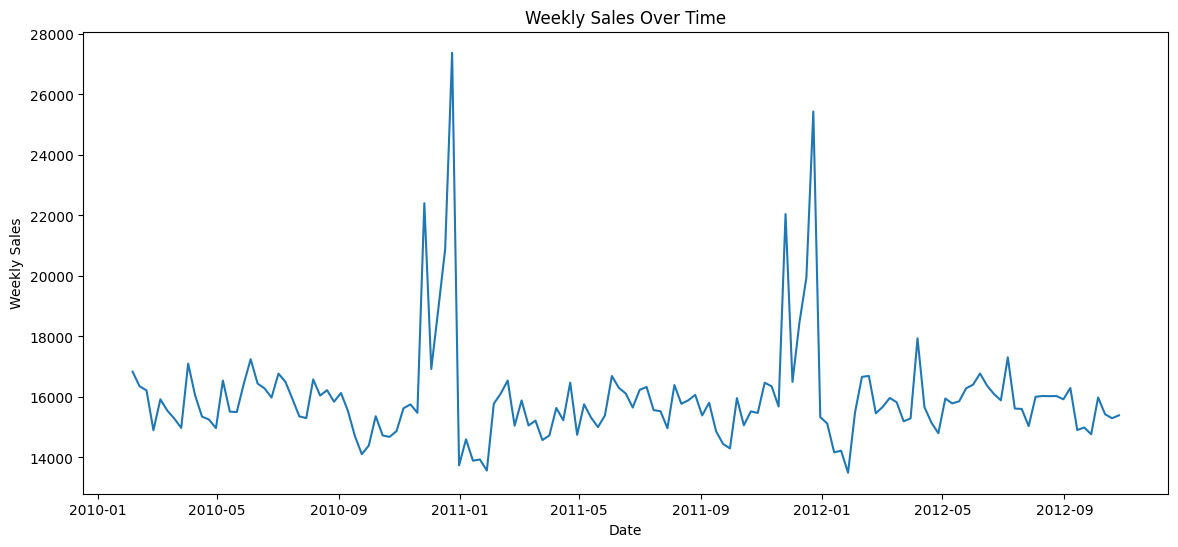

<ipython-input-13-df880d7e4d44>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_merged, x='Type', y='Weekly_Sales', palette='Set3')


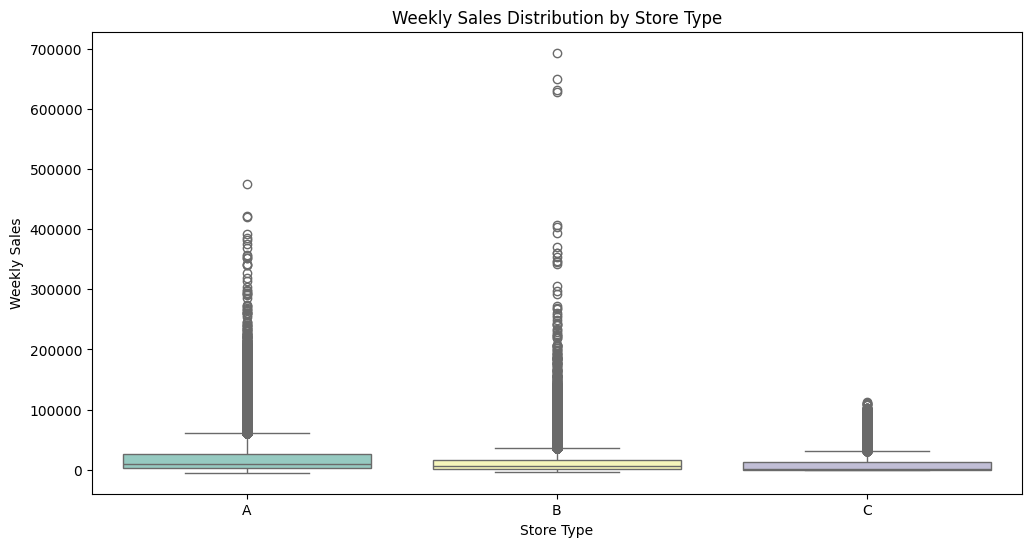

<ipython-input-13-df880d7e4d44>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='viridis')


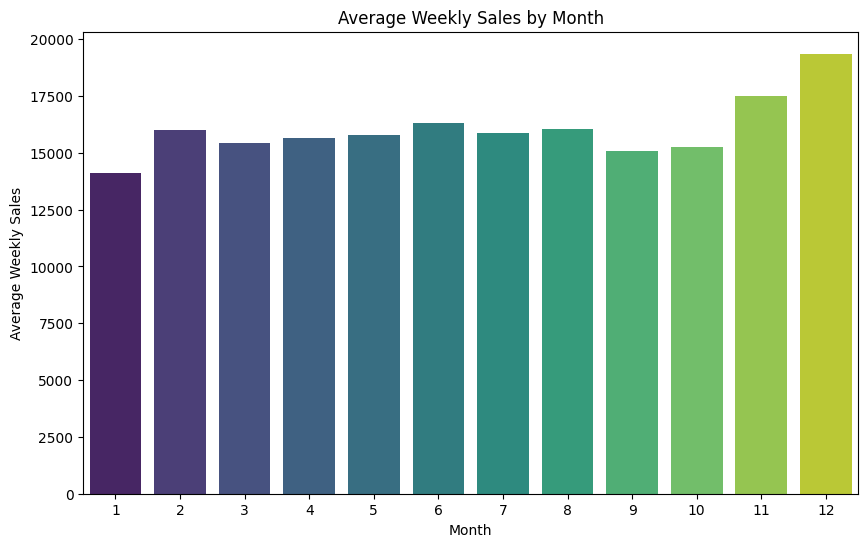

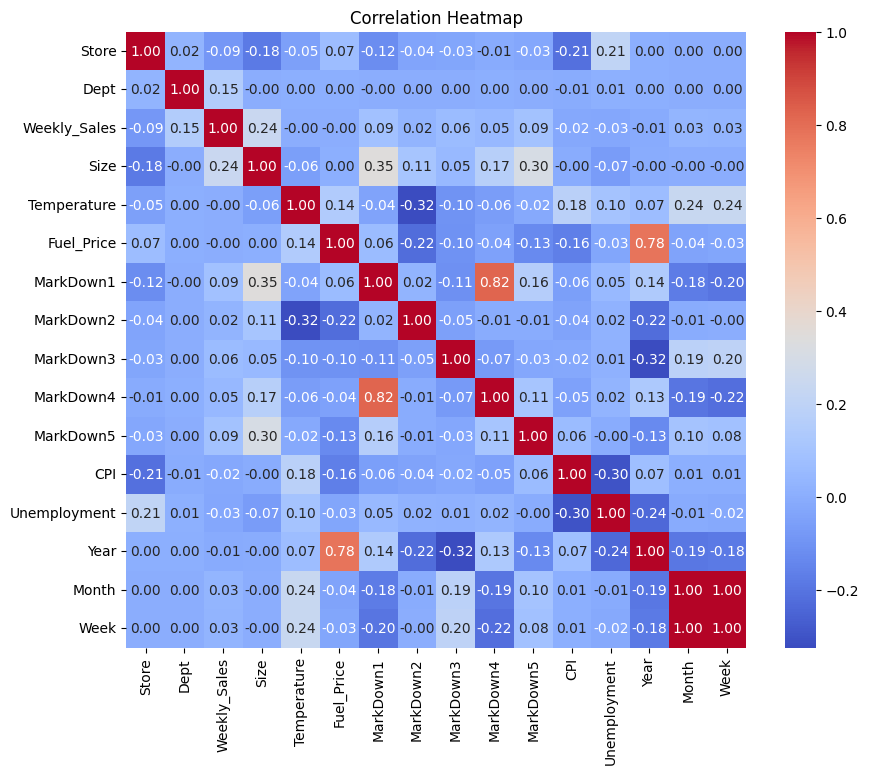

In [ ]:
# Weekly Sales Trend Over Time
plt.figure(figsize=(14, 6))
sns.lineplot(data=train_merged, x='Date', y='Weekly_Sales', ci=None)
plt.title("Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

# Boxplot of Weekly Sales by Store Type
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_merged, x='Type', y='Weekly_Sales', palette='Set3')
plt.title("Weekly Sales Distribution by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.show()

# Average Weekly Sales by Month
monthly_sales = train_merged.groupby('Month')['Weekly_Sales'].mean()
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, palette='viridis')
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

# Correlation Heatmap for Numerical Features
plt.figure(figsize=(10, 8))
# Select only numerical features for correlation calculation
numerical_features = train_merged.select_dtypes(include=['number'])
sns.heatmap(numerical_features.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Ensure 'IsHoliday' exists
if 'IsHoliday' not in train_merged.columns:
    train_merged['IsHoliday'] = train_df['IsHoliday'].astype(int)
if 'IsHoliday' not in test_merged.columns:
    test_merged['IsHoliday'] = test_df['IsHoliday'].astype(int)

print("'IsHoliday' column successfully added.")


'IsHoliday' column successfully added.


In [ ]:
# Lag Features for Weekly Sales
for lag in [1, 2, 3]:
    train_merged[f'Lag_{lag}_Sales'] = train_merged.groupby('Store')['Weekly_Sales'].shift(lag)
    # The test_merged DataFrame does not have a 'Weekly_Sales' column because it's the target variable we're predicting.
    # We should not create lag features for 'Weekly_Sales' in the test set.
    # Instead, we'll add these features later based on the predicted values.
    # For now, initialize these columns with 0.
    test_merged[f'Lag_{lag}_Sales'] = 0

# Fill NA values for lag features in both DataFrames
train_merged.fillna(0, inplace=True)
test_merged.fillna(0, inplace=True) # Fill NA for test_merged

# Feature Selection
feature_cols = [
    'Store', 'Dept', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'CPI',
    'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Lag_1_Sales',
    'Lag_2_Sales', 'Lag_3_Sales'
]
X_train = train_merged[feature_cols]
y_train = train_merged['Weekly_Sales']
X_test = test_merged[feature_cols]

# One-Hot Encoding for Categorical Variables
X_train = pd.get_dummies(X_train, columns=['Type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Type'], drop_first=True)

In [ ]:
# Adding holiday and sales interaction features
train_merged['IsHoliday'] = train_merged['IsHoliday'].astype(int)
test_merged['IsHoliday'] = test_merged['IsHoliday'].astype(int)

# Lag Features for Weekly Sales
for lag in [1, 2, 3]:
    train_merged[f'Lag_{lag}_Sales'] = train_merged.groupby('Store')['Weekly_Sales'].shift(lag)

# Fill NA values for lag features
train_merged.fillna(0, inplace=True)

# Feature Selection
feature_cols = [
    'Store', 'Dept', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'CPI',
    'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Lag_1_Sales', 'Lag_2_Sales', 'Lag_3_Sales'
]
X_train = train_merged[feature_cols]
y_train = train_merged['Weekly_Sales']
X_test = test_merged[feature_cols]

# One-Hot Encoding for Categorical Variables
X_train = pd.get_dummies(X_train, columns=['Type'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Type'], drop_first=True)


In [ ]:
# Feature Selection
feature_cols = [
    'Store', 'Dept', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'CPI',
    'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week'
]
X_train = train_merged[feature_cols]
y_train = train_merged['Weekly_Sales']

# One-Hot Encoding for Categorical Variables
X_train = pd.get_dummies(X_train, columns=['Type'], drop_first=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Train-Test Split
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_split, y_train_split)

# Predictions on Validation Set
y_pred = model.predict(X_val)

# Evaluation Metrics
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
print(f"Validation Mean Squared Error: {mse:.2f}")
print(f"Validation Mean Absolute Error: {mae:.2f}")


Validation Mean Squared Error: 13379852.44
Validation Mean Absolute Error: 1435.33


In [ ]:
# ipython-input-26-7f908b4ea4cb
# Instead of calculating lag features directly on test_merged which does not have 'Weekly_Sales',
# we initialize the lag features with 0 and they will be updated during prediction.
for lag in [1, 2, 3]:
    test_merged[f'Lag_{lag}_Sales'] = 0  # Initialize with 0

# Filling NA values for test_merged with 0
test_merged.fillna(0, inplace=True)

# Feature Selection - Include Lagged Sales for X_train
feature_cols = [
    'Store', 'Dept', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'CPI',
    'Unemployment', 'IsHoliday', 'Year', 'Month', 'Week', 'Lag_1_Sales',
    'Lag_2_Sales', 'Lag_3_Sales'
]
X_train = train_merged[feature_cols] #Selecting specified features for X_train
y_train = train_merged['Weekly_Sales'] #Selecting 'Weekly_Sales' as the target variable
X_test = test_merged[feature_cols] #Selecting specified features for X_test

# One-Hot Encoding for Categorical Variables
X_train = pd.get_dummies(X_train, columns=['Type'], drop_first=True) #Creating dummy variables for 'Type'
X_test = pd.get_dummies(X_test, columns=['Type'], drop_first=True) #Creating dummy variables for 'Type'

In [ ]:
# Lag Features for Weekly Sales (Apply to both train and test datasets)
for lag in [1, 2, 3]:
    train_merged[f'Lag_{lag}_Sales'] = train_merged.groupby('Store')['Weekly_Sales'].shift(lag)
# Fill missing values for lag features in both datasets
train_merged.fillna(0, inplace=True)
test_merged.fillna(0, inplace=True)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
# Aggregate Weekly Sales by Date
time_series_data = train_merged.groupby('Date')['Weekly_Sales'].sum().sort_index()

In [ ]:
# Convert Date to Datetime Index
time_series_data.index = pd.to_datetime(time_series_data.index)

In [ ]:
# Split into Train and Test Sets
train_size = int(len(time_series_data) * 0.8)
train_series, test_series = time_series_data[:train_size], time_series_data[train_size:]

In [ ]:
# Fit ARIMA Model
arima_model = ARIMA(train_series, order=(5, 1, 0))  # Adjust p, d, q as needed
arima_result = arima_model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [ ]:
# Forecast
forecast = arima_result.forecast(steps=len(test_series))

In [ ]:
# Evaluate Model
mse = mean_squared_error(test_series, forecast)
print(f"ARIMA Model MSE: {mse:.2f}")

ARIMA Model MSE: 15398828587656.68


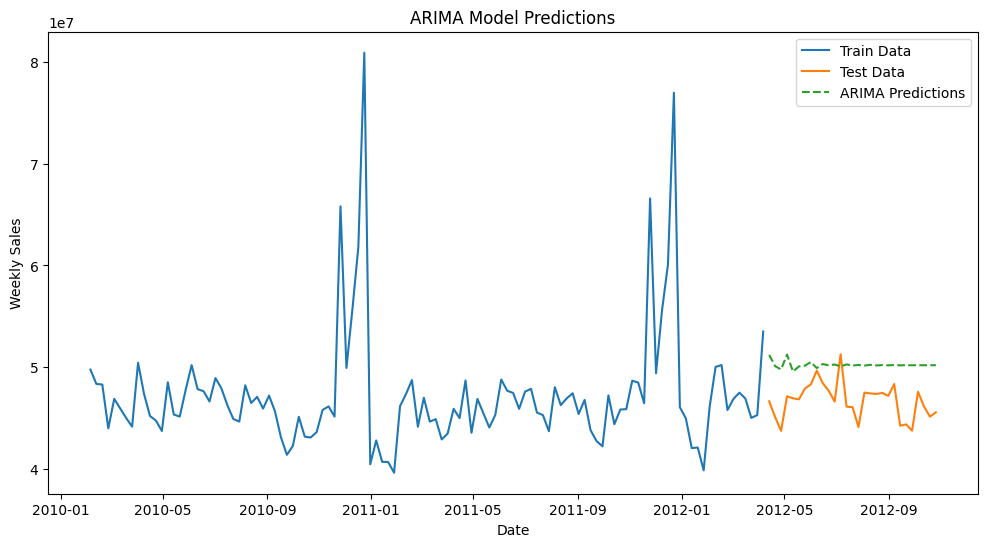

In [ ]:
# Plot Predictions
plt.figure(figsize=(12, 6))
plt.plot(train_series, label="Train Data")
plt.plot(test_series, label="Test Data")
plt.plot(test_series.index, forecast, label="ARIMA Predictions", linestyle="--")
plt.legend()
plt.title("ARIMA Model Predictions")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
# Prepare Data for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(time_series_data.values.reshape(-1, 1))

In [ ]:
# Create Sequence Data
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

seq_length = 12  # Use 12 weeks (3 months) for predictions
X, y = create_sequences(scaled_data, seq_length)

In [ ]:
# Split into Train and Test Sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
# Build LSTM Model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Train LSTM Model
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0536
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0492
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0304 
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0308
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0308
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0259
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0234
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0215
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0241
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0238 
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0202
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0240 
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0217
Epoch 14/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0288
Epoch 15/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0218
Epoch 16/20
4/4 ━━━━━━━━━━━━━━━

In [ ]:
# Predict on Test Data
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Scale back to original values


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step


In [ ]:
# Evaluate Model
mse = mean_squared_error(scaler.inverse_transform(y_test), predictions)
print(f"LSTM Model MSE: {mse:.2f}")


LSTM Model MSE: 3191439958234.58


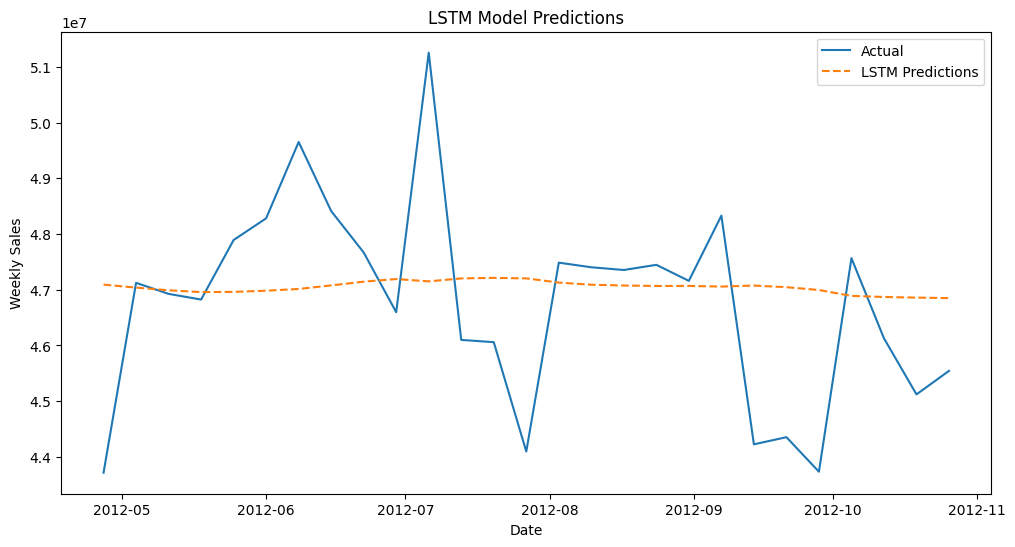

In [ ]:
# Plot Predictions
plt.figure(figsize=(12, 6))
plt.plot(time_series_data.index[-len(y_test):], scaler.inverse_transform(y_test), label="Actual")
plt.plot(time_series_data.index[-len(y_test):], predictions, label="LSTM Predictions", linestyle="--")
plt.legend()
plt.title("LSTM Model Predictions")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()